### Import thư viện

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load các model đã train

In [2]:


lr_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\linear_model.pkl","rb"))
xgb_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\xgboost_model.pkl","rb"))
prophet_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl","rb"))

### Load dataset

In [3]:

df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")


### Xử lý dữ liệu thiếu

In [4]:
df = df.dropna()

### Chuyển cột thời gian

In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [6]:
##  GỘP THEO NGÀY (QUAN TRỌNG)

In [15]:
df['date'] = df['order_purchase_timestamp'].dt.date
df_daily = df.groupby('date')['payment_value'].sum().reset_index()

df_daily.columns = ['date','revenue']
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')


In [16]:
## FEATURE ENGINEERING (GIỐNG TRAIN)

In [17]:
# ==============================
# FEATURE ENGINEERING (MATCH MODEL)
# ==============================

df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

df_daily['lag1'] = df_daily['revenue'].shift(1)
df_daily['lag7'] = df_daily['revenue'].shift(7)
df_daily['lag14'] = df_daily['revenue'].shift(14)

df_daily['rolling7'] = df_daily['revenue'].rolling(7).mean()
df_daily['rolling14'] = df_daily['revenue'].rolling(14).mean()

df_daily = df_daily.dropna()

In [18]:
## SPLIT DATA

In [19]:
test_days = 30

test = df_daily.iloc[-test_days:]

X_test = test.drop(columns=['revenue','date'])
y_test = test['revenue']

In [20]:
## PREDICT

In [21]:

X_test = X_test[lr_model.feature_names_in_]

y_pred_lr = lr_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

In [22]:
## EVALUATE LR & XGB

In [23]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

In [24]:
## PROPHET

In [27]:
df_prophet = df_daily[['date','revenue']].copy()
df_prophet.columns = ['ds','y']

train_p = df_prophet.iloc[:-30]
test_p = df_prophet.iloc[-30:]

# ❗ CHỈ dự đoán đúng khoảng test
future = prophet_model.make_future_dataframe(periods=len(test_p), freq='D')

forecast = prophet_model.predict(future)

# Lấy đúng phần test
forecast_test = forecast.iloc[-len(test_p):]

y_pred_prophet = forecast_test['yhat'].values
y_true_prophet = test_p['y'].values

In [28]:
## EVALUATE PROPHET

In [29]:
mae_prophet = mean_absolute_error(y_true_prophet, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_true_prophet, y_pred_prophet))
r2_prophet = r2_score(y_true_prophet, y_pred_prophet)

In [30]:
## SO SÁNH

In [31]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Prophet"],
    "MAE": [mae_lr, mae_xgb, mae_prophet],
    "RMSE": [rmse_lr, rmse_xgb, rmse_prophet],
    "R2": [r2_lr, r2_xgb, r2_prophet]
})

print(results)

               Model           MAE          RMSE        R2
0  Linear Regression   8202.562579  10801.696269  0.384480
1            XGBoost   1859.441711   2378.011674  0.970168
2            Prophet  11607.086115  14190.187971 -0.062269


In [32]:
## VISUALIZE

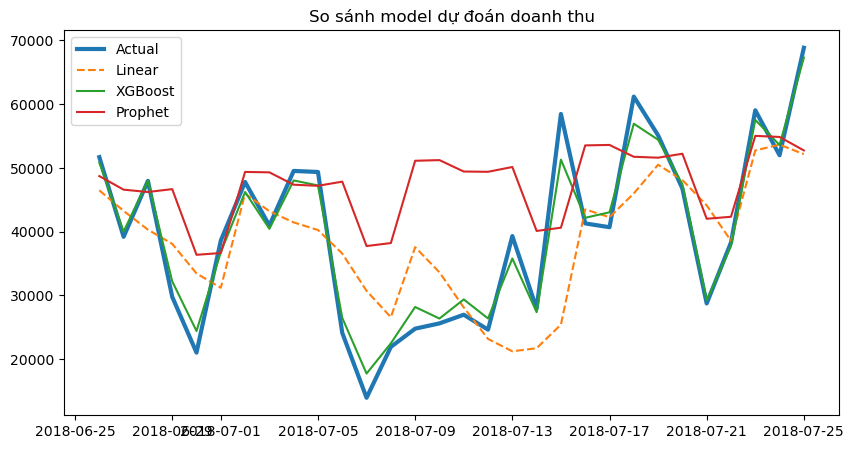

In [33]:
plt.figure(figsize=(10,5))
plt.plot(test['date'], y_test, label='Actual', linewidth=3)
plt.plot(test['date'], y_pred_lr, label='Linear', linestyle='--')
plt.plot(test['date'], y_pred_xgb, label='XGBoost')
plt.plot(test['date'], y_pred_prophet, label='Prophet')
plt.legend()
plt.title("So sánh model dự đoán doanh thu")
plt.show()

               Model       MAE      RMSE      R2
0  Linear Regression   8202.56  10801.70  0.3845
1            XGBoost   1859.44   2378.01  0.9702
2            Prophet  11607.09  14190.19 -0.0623


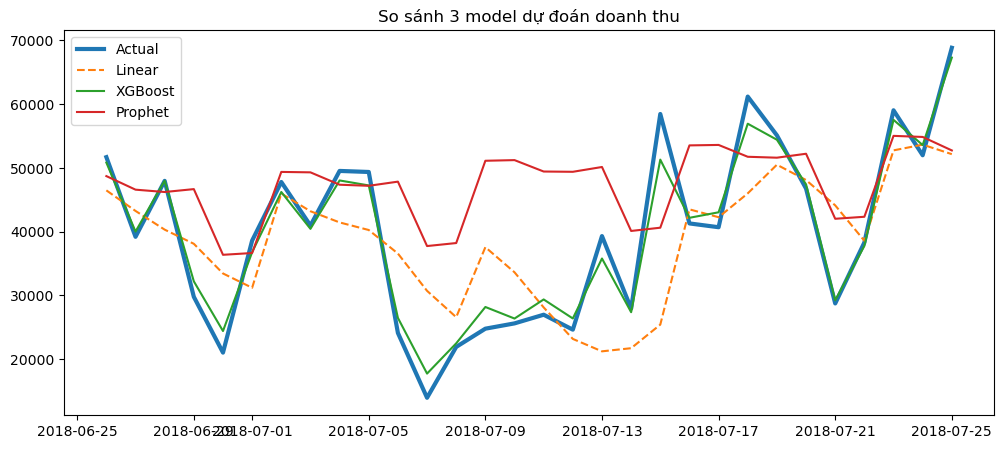

In [34]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ================= LOAD MODEL =================
lr_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\linear_model.pkl","rb"))
xgb_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\xgboost_model.pkl","rb"))
prophet_model = pickle.load(open(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\models\prophet_model.pkl","rb"))

# ================= LOAD DATA =================
df = pd.read_csv(r"D:\UNIVERSITY\ĐACN\BI-Dashboard-Project\data\live\sales_dashboard.csv")
df = df.dropna()

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# ================= DAILY =================
df['date'] = df['order_purchase_timestamp'].dt.date
df_daily = df.groupby('date')['payment_value'].sum().reset_index()

df_daily.columns = ['date','revenue']
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values('date')

# ================= FEATURE ENGINEERING =================
df_daily['dayofweek'] = df_daily['date'].dt.dayofweek
df_daily['month'] = df_daily['date'].dt.month

df_daily['lag1'] = df_daily['revenue'].shift(1)
df_daily['lag7'] = df_daily['revenue'].shift(7)
df_daily['lag14'] = df_daily['revenue'].shift(14)

df_daily['rolling7'] = df_daily['revenue'].rolling(7).mean()
df_daily['rolling14'] = df_daily['revenue'].rolling(14).mean()

df_daily = df_daily.dropna()

# ================= SPLIT =================
test_days = 30

train = df_daily.iloc[:-test_days]
test = df_daily.iloc[-test_days:]

X_test = test.drop(columns=['revenue','date'])
y_test = test['revenue']

# ⚠️ ÉP đúng feature như lúc train
FEATURES = ['dayofweek','month','lag1','lag7','lag14','rolling7','rolling14']
X_test = X_test[FEATURES]

# ================= PREDICT =================
y_pred_lr = lr_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# ================= EVALUATE =================
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return round(mae,2), round(rmse,2), round(r2,4)

mae_lr, rmse_lr, r2_lr = evaluate(y_test, y_pred_lr)
mae_xgb, rmse_xgb, r2_xgb = evaluate(y_test, y_pred_xgb)

# ================= PROPHET =================
df_prophet = df_daily[['date','revenue']].copy()
df_prophet.columns = ['ds','y']

train_p = df_prophet.iloc[:-test_days]
test_p = df_prophet.iloc[-test_days:]

future = prophet_model.make_future_dataframe(periods=test_days)
forecast = prophet_model.predict(future)

forecast_test = forecast.tail(test_days)

y_pred_prophet = forecast_test['yhat'].values
y_true_prophet = test_p['y'].values

mae_prophet, rmse_prophet, r2_prophet = evaluate(y_true_prophet, y_pred_prophet)

# ================= RESULT =================
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Prophet"],
    "MAE": [mae_lr, mae_xgb, mae_prophet],
    "RMSE": [rmse_lr, rmse_xgb, rmse_prophet],
    "R2": [r2_lr, r2_xgb, r2_prophet]
})

print(results)

# ================= VISUALIZE =================
plt.figure(figsize=(12,5))

plt.plot(test['date'], y_test.values, label='Actual', linewidth=3)
plt.plot(test['date'], y_pred_lr, label='Linear', linestyle='--')
plt.plot(test['date'], y_pred_xgb, label='XGBoost')
plt.plot(test['date'], y_pred_prophet, label='Prophet')

plt.legend()
plt.title("So sánh 3 model dự đoán doanh thu")
plt.show()